In [32]:
import jax.numpy as jnp
from typing import Tuple
from datasets import load_dataset
from jax.nn import one_hot

def load_mnist_data() -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray, jnp.ndarray]:
    """Load and preprocess MNIST dataset using Hugging Face datasets with JAX format."""
    print("Loading MNIST dataset from Hugging Face with JAX format...")
    
    # Load dataset from Hugging Face with JAX format
    mnist_dataset = load_dataset("fashion_mnist", cache_dir="~/.cache/huggingface/datasets").with_format("jax")
    
    # Extract train and test sets directly as JAX arrays
    train_data = mnist_dataset["train"]
    test_data = mnist_dataset["test"]
    
    # Extract images and reshape to 28x28
    x_train = jnp.array([img.reshape(28, 28) for img in train_data["image"]])
    y_train = jnp.array(train_data["label"])
    
    x_test = jnp.array([img.reshape(28, 28) for img in test_data["image"]])
    y_test = jnp.array(test_data["label"])
    
    # Normalize data
    x_train = x_train.astype(jnp.float32) / 255.0
    x_test = x_test.astype(jnp.float32) / 255.0
    
    # Convert labels to one-hot encoding
    y_train = one_hot(y_train, 10)
    y_test = one_hot(y_test, 10)
    
    print("x_train shape:", x_train.shape)
    print("y_train shape:", y_train.shape)
    print("x_test shape:", x_test.shape)
    print("y_test shape:", y_test.shape)
    
    return x_train, y_train, x_test, y_test
x_train, y_train, x_test, y_test = load_mnist_data()


Loading MNIST dataset from Hugging Face with JAX format...


Generating test split: 100%|██████████| 10000/10000 [00:00<00:00, 1012529.93 examples/s]


x_train shape: (60000, 28, 28)
y_train shape: (60000, 10)
x_test shape: (10000, 28, 28)
y_test shape: (10000, 10)


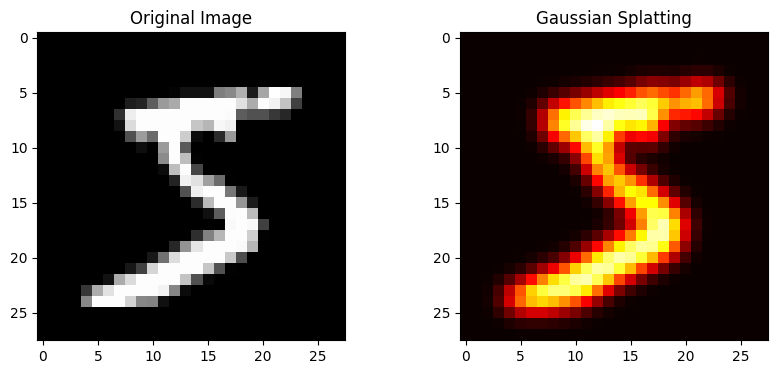

In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt


image = x_train[0]

# Extract non-zero pixel coordinates and intensities
coords = jnp.argwhere(image > 0.05)  # Shape: (N, 2)
intensities = image[coords[:, 0], coords[:, 1]]  # Shape: (N,)

# Gaussian parameters
sigma = 1.0
H, W = image.shape
xx, yy = jnp.meshgrid(jnp.arange(H), jnp.arange(W), indexing='ij')  # Shape: (H, W)

# Render Gaussian splats
def splat_gaussians(coords, intensities, sigma, H, W):
    canvas = jnp.zeros((H, W))

    def body(i, acc):
        y, x = coords[i]
        intensity = intensities[i]
        gauss = jnp.exp(-((xx - y) ** 2 + (yy - x) ** 2) / (2 * sigma ** 2))
        return acc + gauss * intensity

    canvas = jax.lax.fori_loop(0, coords.shape[0], body, canvas)
    return canvas

splat_image = splat_gaussians(coords, intensities, sigma, H, W)

# Plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Gaussian Splatting")
plt.imshow(splat_image, cmap='hot')
plt.show()

Step 0, Loss: 1.631225
Step 100, Loss: 0.223361
Step 200, Loss: 0.097500
Step 300, Loss: 0.057810
Step 400, Loss: 0.039809
Step 500, Loss: 0.029769
Step 600, Loss: 0.023604
Step 700, Loss: 0.019285
Step 800, Loss: 0.016186
Step 900, Loss: 0.013837
Step 1000, Loss: 0.012090
Step 1100, Loss: 0.010742
Step 1200, Loss: 0.009538
Step 1300, Loss: 0.008444
Step 1400, Loss: 0.007573
Step 1500, Loss: 0.006935
Step 1600, Loss: 0.006318
Step 1700, Loss: 0.005779
Step 1800, Loss: 0.005309
Step 1900, Loss: 0.004869


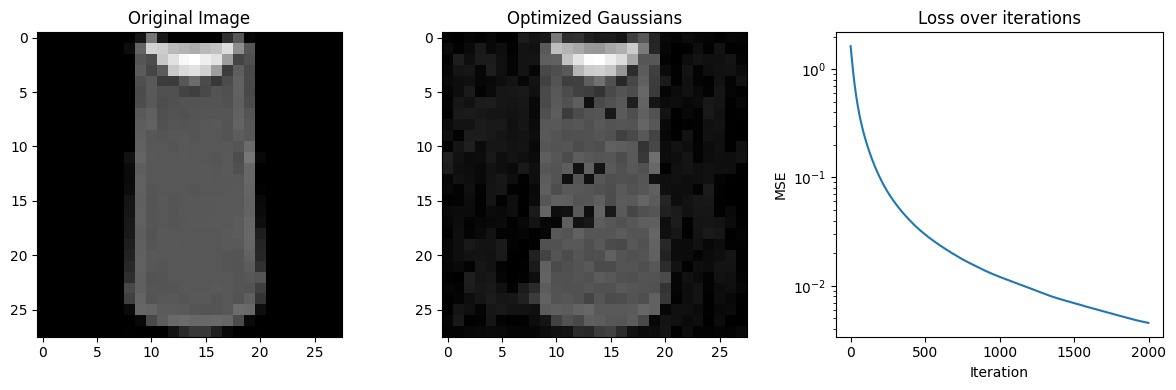

In [38]:
import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt
from functools import partial

def initialize_learnable_gaussians(coords, intensities, num_gaussians=None):
    """Initialize learnable Gaussian parameters from pixel data or randomly."""
    if num_gaussians is None and coords is not None:
        num_gaussians = len(coords)
        # Initialize from existing image data
        positions = jnp.array(coords, dtype=float)  # (N, 2) - y, x coordinates
        amplitudes = jnp.array(intensities, dtype=float).reshape(-1, 1)  # (N, 1)
    else:
        if num_gaussians is None:
            num_gaussians = 100  # Default number of Gaussians
            
        # Initialize randomly
        H, W = 28, 28  # Assuming MNIST dimensions
        key1, key2, key3 = jax.random.split(jax.random.PRNGKey(0), 3)
        positions = jnp.stack([
            jax.random.uniform(key1, (num_gaussians,), minval=0, maxval=H),
            jax.random.uniform(key2, (num_gaussians,), minval=0, maxval=W)
        ], axis=1)
        amplitudes = jax.random.uniform(key3, (num_gaussians, 1), minval=0, maxval=1)
    
    # Anisotropic covariance parameters (scale and rotation)
    # Scale: log-space for numerical stability
    scales = jnp.ones((num_gaussians, 2)) * jnp.log(1.0)  # (N, 2) - scale_y, scale_x
    
    # Rotation in radians
    rotations = jnp.zeros((num_gaussians, 1)) + 1  # (N, 1)
    
    return {
        'positions': positions,    # (N, 2) - y, x coordinates
        'scales': scales,          # (N, 2) - scale_y, scale_x in log space
        'rotations': rotations,    # (N, 1) - rotation in radians
        'amplitudes': amplitudes   # (N, 1) - intensity/opacity
    }

def gaussian_covariance(scale_y, scale_x, rotation):
    """Compute the covariance matrix for an anisotropic Gaussian."""
    # Convert from log-space
    scale_y, scale_x = jnp.exp(scale_y), jnp.exp(scale_x)
    scale_y = jnp.exp(jnp.ones_like(scale_y) )
    
    # Compute rotation matrix elements
    cos_r, sin_r = jnp.cos(rotation), jnp.sin(rotation)
    
    # Covariance matrix elements
    a = scale_y**2 * cos_r**2 + scale_x**2 * sin_r**2
    b = (scale_y**2 - scale_x**2) * cos_r * sin_r
    c = scale_y**2 * sin_r**2 + scale_x**2 * cos_r**2
    
    return a, b, c

def render_gaussians(params, H, W):
    """Render all Gaussians onto a canvas."""
    # Create coordinate grid
    yy, xx = jnp.mgrid[0:H, 0:W]
    coords_grid = jnp.stack([yy, xx], axis=-1)  # (H, W, 2)
    
    # Initialize canvas
    canvas = jnp.zeros((H, W))
    
    def render_single_gaussian(i, canvas):
        # Extract parameters for this Gaussian
        pos_y, pos_x = params['positions'][i]
        scale_y, scale_x = params['scales'][i]
        rotation = params['rotations'][i][0]
        amplitude = jnp.exp(params['amplitudes'][i][0])
        
        # Compute position offset for each pixel
        delta = coords_grid - jnp.array([pos_y, pos_x])  # (H, W, 2)
        
        # Compute covariance matrix elements
        a, b, c = gaussian_covariance(scale_y, scale_x, rotation)
        
        # Compute quadratic form: [dy, dx] * cov_inv * [dy, dx]^T
        dy, dx = delta[..., 0], delta[..., 1]
        quad = a * dy**2 + 2 * b * dy * dx + c * dx**2
        
        # Compute Gaussian
        gaussian = amplitude * jnp.exp(-0.5 * quad)
        
        # Add to canvas (alpha blending)
        return canvas + gaussian
    
    # Render all Gaussians
    canvas = jax.lax.fori_loop(0, params['positions'].shape[0], render_single_gaussian, canvas)
    
    return canvas

@jax.jit
def compute_loss(params, target_image):
    """Compute MSE loss between rendered image and target."""
    H, W = target_image.shape
    rendered = render_gaussians(params, H, W)
    return jnp.mean((rendered - target_image) ** 2)

def optimize_gaussians(params, target_image, steps=2000, learning_rate=0.01):
    """Optimize Gaussian parameters to fit the target image."""
    H, W = target_image.shape
    
    # Setup optimizer
    optimizer = optax.adam(learning_rate)
    opt_state = optimizer.init(params)
    
    # Define a JIT-compiled update step with the optimizer fixed
    @jax.jit
    def update_step(params, opt_state, target_image):
        """Perform one optimization step."""
        loss, grads = jax.value_and_grad(compute_loss)(params, target_image)
        updates, new_opt_state = optimizer.update(grads, opt_state)
        new_params = optax.apply_updates(params, updates)
        new_params = {
            'positions': new_params['positions'],
            'scales': params['scales'],
            'rotations': params['rotations'],
            'amplitudes': new_params['amplitudes']
        }
        return new_params, new_opt_state, loss
    
    losses = []
    
    # Optimization loop
    for step in range(steps):
        params, opt_state, loss = update_step(params, opt_state, target_image)
        losses.append(float(loss))
        
        if step % 100 == 0:
            print(f"Step {step}, Loss: {loss:.6f}")
    
    # Final rendering
    final_render = render_gaussians(params, H, W)
    
    return params, final_render, losses

image = x_train[2]  # Target image
coords = jnp.argwhere(image > 0.05)
intensities = image[coords[:, 0], coords[:, 1]]

# Initialize learnable parameters from the image
# params = initialize_learnable_gaussians(coords, intensities)

# Or with a fixed number of Gaussians
params = initialize_learnable_gaussians(None, None, num_gaussians=200)

# Optimize the parameters
optimized_params, final_render, losses = optimize_gaussians(params, image)

# Visualize results
plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(image, cmap='gray')
plt.title("Original Image")

plt.subplot(132)
plt.imshow(final_render, cmap='gray')
plt.title("Optimized Gaussians")

plt.subplot(133)
plt.plot(losses)
plt.title("Loss over iterations")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.yscale('log')

plt.tight_layout()
plt.show()

In [4]:
import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt
from functools import partial

def initialize_learnable_gaussians(coords, intensities, num_gaussians=None):
    """Initialize learnable Gaussian parameters from pixel data or randomly."""
    if num_gaussians is None and coords is not None:
        num_gaussians = len(coords)
        # Initialize from existing image data
        positions = jnp.array(coords, dtype=float)  # (N, 2) - y, x coordinates
        amplitudes = jnp.array(intensities, dtype=float).reshape(-1, 1)  # (N, 1)
    else:
        if num_gaussians is None:
            num_gaussians = 100  # Default number of Gaussians
            
        # Initialize randomly
        H, W = 28, 28  # Assuming MNIST dimensions
        key1, key2, key3 = jax.random.split(jax.random.PRNGKey(0), 3)
        positions = jnp.stack([
            jax.random.uniform(key1, (num_gaussians,), minval=0, maxval=H),
            jax.random.uniform(key2, (num_gaussians,), minval=0, maxval=W)
        ], axis=1)
        amplitudes = jax.random.uniform(key3, (num_gaussians, 1), minval=0, maxval=1)
    
    # Anisotropic covariance parameters (scale and rotation)
    # Scale: log-space for numerical stability
    scales = jnp.ones((num_gaussians, 2)) * jnp.log(1.0)  # (N, 2) - scale_y, scale_x
    
    # Rotation in radians
    rotations = jnp.zeros((num_gaussians, 1))  # (N, 1)
    
    return {
        'positions': positions,    # (N, 2) - y, x coordinates
        'scales': scales,          # (N, 2) - scale_y, scale_x in log space
        'rotations': rotations,    # (N, 1) - rotation in radians
        'amplitudes': amplitudes   # (N, 1) - intensity/opacity
    }

def gaussian_covariance(scale_y, scale_x, rotation):
    """Compute the covariance matrix for an anisotropic Gaussian."""
    # Convert from log-space
    scale_y, scale_x = jnp.exp(scale_y), jnp.exp(scale_x)
    
    # Compute rotation matrix elements
    cos_r, sin_r = jnp.cos(rotation), jnp.sin(rotation)
    
    # Covariance matrix elements
    a = scale_y**2 * cos_r**2 + scale_x**2 * sin_r**2
    b = (scale_y**2 - scale_x**2) * cos_r * sin_r
    c = scale_y**2 * sin_r**2 + scale_x**2 * cos_r**2
    
    return a, b, c

def render_gaussians(params, H, W, visualize_individual=False):
    """
    Render all Gaussians onto a canvas.
    
    Args:
        params: Gaussian parameters
        H, W: Height and width of the output image
        visualize_individual: If True, return a separate image for each Gaussian
        
    Returns:
        canvas: Combined rendering of all Gaussians
        individual_gaussians: (Optional) List of individual Gaussian renderings
    """
    # Create coordinate grid
    yy, xx = jnp.mgrid[0:H, 0:W]
    coords_grid = jnp.stack([yy, xx], axis=-1)  # (H, W, 2)
    
    # Initialize canvas
    canvas = jnp.zeros((H, W))
    individual_gaussians = [] if visualize_individual else None
    
    def render_single_gaussian(i, canvas):
        # Extract parameters for this Gaussian
        pos_y, pos_x = params['positions'][i]
        scale_y, scale_x = params['scales'][i]
        rotation = params['rotations'][i][0]
        amplitude = params['amplitudes'][i][0]
        
        # Compute position offset for each pixel
        delta = coords_grid - jnp.array([pos_y, pos_x])  # (H, W, 2)
        
        # Compute covariance matrix elements
        a, b, c = gaussian_covariance(scale_y, scale_x, rotation)
        
        # Compute quadratic form: [dy, dx] * cov_inv * [dy, dx]^T
        dy, dx = delta[..., 0], delta[..., 1]
        quad = a * dy**2 + 2 * b * dy * dx + c * dx**2
        
        # Compute Gaussian
        gaussian = amplitude * jnp.exp(-0.5 * quad)
        
        # Store individual Gaussian if requested
        if visualize_individual:
            individual_gaussians.append(np.array(gaussian))
        
        # Add to canvas (alpha blending)
        return canvas + gaussian
    
    # Render all Gaussians
    canvas = jax.lax.fori_loop(0, params['positions'].shape[0], render_single_gaussian, canvas)
    
    if visualize_individual:
        return canvas, individual_gaussians
    else:
        return canvas

@jax.jit
def compute_loss(params, target_image):
    """Compute MSE loss between rendered image and target."""
    H, W = target_image.shape
    rendered = render_gaussians(params, H, W)
    return jnp.mean((rendered - target_image) ** 2)

def optimize_gaussians(params, target_image, steps=1000, learning_rate=0.01, save_frames=False, frame_interval=10):
    """Optimize Gaussian parameters to fit the target image.
    
    Args:
        params: Initial Gaussian parameters
        target_image: Target image to fit
        steps: Number of optimization steps
        learning_rate: Learning rate for optimizer
        save_frames: Whether to save intermediate renders for animation
        frame_interval: How often to save frames (every N steps)
    
    Returns:
        params: Optimized parameters
        final_render: Final rendered image
        losses: List of loss values
        frames: List of intermediate renders (if save_frames=True)
    """
    H, W = target_image.shape
    
    # Setup optimizer
    optimizer = optax.adam(learning_rate)
    opt_state = optimizer.init(params)
    
    # Define a JIT-compiled update step with the optimizer fixed
    @jax.jit
    def update_step(params, opt_state, target_image):
        """Perform one optimization step."""
        loss, grads = jax.value_and_grad(compute_loss)(params, target_image)
        updates, new_opt_state = optimizer.update(grads, opt_state)
        new_params = optax.apply_updates(params, updates)
        return new_params, new_opt_state, loss
    
    losses = []
    frames = [] if save_frames else None
    
    # Optimization loop
    for step in range(steps):
        params, opt_state, loss = update_step(params, opt_state, target_image)
        losses.append(float(loss))
        
        # Save frame if requested
        if save_frames and (step % frame_interval == 0 or step == steps - 1):
            frame = render_gaussians(params, H, W)
            frames.append(np.array(frame))
            
        if step % 100 == 0:
            print(f"Step {step}, Loss: {loss:.6f}")
    
    # Final rendering
    final_render = render_gaussians(params, H, W)
    
    if save_frames:
        return params, final_render, losses, frames
    else:
        return params, final_render, losses

# Function to create animation of optimization process
def create_optimization_animation(image, num_gaussians=None, steps=300, learning_rate=0.01, 
                                 frame_interval=5, fps=10, save_path=None, format='mp4'):
    """
    Create and display an animation of the Gaussian splatting optimization process.
    
    Args:
        image: Target image to reconstruct
        num_gaussians: Number of Gaussians to use (None to use non-zero pixels)
        steps: Number of optimization steps
        learning_rate: Learning rate for optimizer
        frame_interval: Save a frame every N steps
        fps: Frames per second in the animation
        save_path: Optional path to save the animation
        format: Format to save animation ('mp4', 'gif')
    """
    from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
    import matplotlib.pyplot as plt
    from IPython.display import display, HTML
    
    # Setup
    H, W = image.shape
    
    if num_gaussians is None:
        # Initialize from image
        coords = jnp.argwhere(image > 0.05)
        intensities = image[coords[:, 0], coords[:, 1]]
        params = initialize_learnable_gaussians(coords, intensities)
        print(f"Using {len(coords)} Gaussians based on non-zero pixels")
    else:
        # Initialize randomly
        params = initialize_learnable_gaussians(None, None, num_gaussians=num_gaussians)
        print(f"Using {num_gaussians} randomly initialized Gaussians")
    
    # Optimize with frame saving
    optimized_params, final_render, losses, frames = optimize_gaussians(
        params, image, steps=steps, learning_rate=learning_rate, 
        save_frames=True, frame_interval=frame_interval
    )
    
    # Create the animation
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image (static)
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title("Target Image")
    axes[0].axis('off')
    
    # Optimization progress (animated)
    im = axes[1].imshow(frames[0], cmap='gray', vmin=0, vmax=image.max())
    axes[1].set_title("Gaussian Reconstruction")
    axes[1].axis('off')
    
    # Plot for loss values (will be updated)
    loss_line, = axes[2].plot([], [], 'b-')
    axes[2].set_title("Optimization Loss")
    axes[2].set_xlabel("Step")
    axes[2].set_ylabel("MSE Loss")
    axes[2].set_yscale('log')
    axes[2].set_xlim(0, steps)
    if len(losses) > 0:
        min_loss, max_loss = min(losses), max(losses)
        axes[2].set_ylim(min_loss * 0.9, max_loss * 1.1)
    
    # Add a text annotation for the step number and loss
    step_text = axes[1].text(0.05, 0.95, "", transform=axes[1].transAxes, 
                            color='white', backgroundcolor='black')
    
    total_frames = len(frames)
    actual_steps = list(range(0, steps, frame_interval)) + [steps-1]
    if len(actual_steps) > total_frames:
        actual_steps = actual_steps[:total_frames]
    
    def update(frame_idx):
        # Update the image
        im.set_data(frames[frame_idx])
        
        # Update the step text
        step_num = actual_steps[frame_idx]
        if step_num < len(losses):
            loss_val = losses[step_num]
            step_text.set_text(f"Step: {step_num}, Loss: {loss_val:.6f}")
            
            # Update loss plot
            loss_line.set_data(range(step_num + 1), losses[:step_num + 1])
        
        return [im, step_text, loss_line]
    
    anim = FuncAnimation(fig, update, frames=total_frames, interval=1000/fps, blit=True)
    plt.close()  # Prevent duplicate display in notebooks
    
    # Save animation if requested
    if save_path:
        if format.lower() == 'mp4':
            # Save as MP4 using FFmpeg
            writer = FFMpegWriter(fps=fps, metadata=dict(artist='Me'), bitrate=1800)
            anim.save(save_path, writer=writer)
        elif format.lower() == 'gif':
            # Save as GIF using Pillow
            writer = PillowWriter(fps=fps)
            anim.save(save_path, writer=writer)
        else:
            raise ValueError(f"Unsupported format: {format}. Use 'mp4' or 'gif'.")
        print(f"Animation saved to {save_path}")
    
    # Display the animation in a notebook
    return HTML(anim.to_jshtml())

# Function to visualize individual Gaussians
def visualize_gaussians(params, image, max_gaussians=20):
    """
    Visualize individual Gaussians along with their combined rendering.
    
    Args:
        params: Gaussian parameters
        image: Original target image
        max_gaussians: Maximum number of individual Gaussians to display
    """
    H, W = image.shape
    canvas, individual_gaussians = render_gaussians(params, H, W, visualize_individual=True)
    
    # Limit the number of Gaussians to display
    n_gaussians = min(len(individual_gaussians), max_gaussians)
    individual_gaussians = individual_gaussians[:n_gaussians]
    
    # Create a grid layout for plotting
    rows = int(np.ceil(np.sqrt(n_gaussians + 2)))
    cols = int(np.ceil((n_gaussians + 2) / rows))
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
    axes = axes.flatten()
    
    # Plot original image
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title("Original Image")
    axes[0].axis('off')
    
    # Plot combined rendering
    axes[1].imshow(canvas, cmap='gray')
    axes[1].set_title(f"Combined ({len(params['positions'])} Gaussians)")
    axes[1].axis('off')
    
    # Plot individual Gaussians
    for i, gaussian in enumerate(individual_gaussians):
        if i + 2 < len(axes):
            ax = axes[i + 2]
            ax.imshow(gaussian, cmap='gray')
            y, x = params['positions'][i]
            scale_y, scale_x = np.exp(params['scales'][i])
            rotation = params['rotations'][i][0] * 180 / np.pi  # Convert to degrees
            amplitude = params['amplitudes'][i][0]
            ax.set_title(f"G{i}: ({y:.1f},{x:.1f}), σ=({scale_y:.1f},{scale_x:.1f})\n"
                         f"rot={rotation:.1f}°, amp={amplitude:.2f}")
            ax.axis('off')
    
    # Hide empty subplots
    for i in range(n_gaussians + 2, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

In [11]:
# Example code to create and save an MP4 animation of the Gaussian splatting process

# Assuming you have MNIST data loaded
image = x_train[17]  # Use first MNIST digit or your own image

# Create animation with MP4 output
animation = create_optimization_animation(
    image, 
    num_gaussians=50,  
    steps=500,         
    learning_rate=0.02,
    frame_interval=3,  # Save a frame every 3 steps (for smoother animation)
    fps=10,            # Higher FPS for smoother playback
    save_path="gaussian_splatting_3.mp4",  # Save as MP4
    format='mp4'
)

# Display the animation in the notebook
display(animation)


Using 50 randomly initialized Gaussians


KeyboardInterrupt: 